In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import optuna
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import MAE
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Perform Appropriate Scaling and Validation Data split

In [102]:
map_forecast_path = "data/map-forecast"
df_train_full = pd.read_csv(f"{map_forecast_path}/dataframe/df_map_train.csv")
df_test = pd.read_csv(f"{map_forecast_path}/dataframe/df_map_test.csv")
# get list of unique stay_id
train_ids = list(set(df_train_full['stay_id'].values))
test_ids = list(set(df_test['stay_id'].values))
print(test_ids)
df_train_full

[np.int64(34617352), np.int64(39804682), np.int64(37057036), np.int64(37323533), np.int64(31959184), np.int64(35024147), np.int64(30913302), np.int64(36091287), np.int64(30585761), np.int64(31338022), np.int64(34592300), np.int64(35436337), np.int64(32391858), np.int64(35544374), np.int64(32283063), np.int64(35727289), np.int64(38197705), np.int64(32155744), np.int64(34531557), np.int64(32453351), np.int64(31316840), np.int64(36107367), np.int64(34170353), np.int64(31205490), np.int64(30849778), np.int64(35044342)]


,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,Temperature Fahrenheit,PEEP set,GCS - Motor Response,NaCl 0.9%,Norepinephrine
0,37067082,2157-11-20 19:00:00,104.0,55.0,1.0,86.0,18.0,98.5,0.0,6.0,35.131745,0.0
1,37067082,2157-11-20 20:00:00,95.0,55.0,1.0,91.0,24.0,98.5,0.0,6.0,75.282311,0.0
2,37067082,2157-11-20 21:00:00,103.0,55.0,1.0,95.0,25.0,98.5,0.0,6.0,75.282311,0.0
3,37067082,2157-11-20 22:00:00,93.0,55.0,1.0,102.0,27.0,99.1,0.0,6.0,75.282311,0.0
4,37067082,2157-11-20 23:00:00,88.0,55.0,1.0,106.0,20.0,99.1,0.0,6.0,75.282311,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9312,36893762,2134-09-08 17:00:00,99.0,67.0,1.0,99.0,21.0,98.6,0.0,6.0,0.000000,0.0
9313,36893762,2134-09-08 18:00:00,101.0,67.0,1.0,103.0,20.0,98.6,0.0,6.0,0.000000,0.0
9314,36893762,2134-09-08 19:00:00,92.0,67.0,1.0,94.0,17.0,98.6,0.0,6.0,0.000000,0.0
9315,36893762,2134-09-08 20:00:00,108.0,67.0,1.0,97.0,17.0,98.6,0.0,6.0,0.000000,0.0


In [3]:
# Obtain train-val split for validation set
# 1. Get unique Stay IDs
unique_stays = df_train_full['stay_id'].unique()

# 2. Randomly shuffle and split
np.random.seed(42) # Use seed for reproducibility
np.random.shuffle(unique_stays)

train_size = int(len(unique_stays) * 0.85)
train_ids = unique_stays[:train_size]
val_ids = unique_stays[train_size:]

# 3. Create the dataframes
df_train = df_train_full[df_train_full['stay_id'].isin(train_ids)]
df_val = df_train_full[df_train_full['stay_id'].isin(val_ids)]

df_val

,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,Temperature Fahrenheit,PEEP set,GCS - Motor Response,NaCl 0.9%,Norepinephrine
27,34807493,2156-04-30 22:00:00,112.0,81.0,1.0,107.0,25.5,98.4,5.0,5.0,5.0,0.0
28,34807493,2156-04-30 23:00:00,51.0,81.0,1.0,105.0,22.0,98.4,5.0,5.0,5.0,0.0
29,34807493,2156-05-01 00:00:00,59.0,81.0,1.0,98.0,29.0,98.4,5.0,5.0,5.0,0.0
30,34807493,2156-05-01 01:00:00,63.0,81.0,1.0,87.0,23.0,98.4,5.0,5.0,5.0,0.0
31,34807493,2156-05-01 02:00:00,59.0,81.0,1.0,86.0,25.0,98.4,5.0,5.0,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
9284,39142259,2115-12-30 05:00:00,75.0,57.0,1.0,103.0,27.0,98.7,0.0,6.0,0.0,0.0
9285,39142259,2115-12-30 06:00:00,79.0,57.0,1.0,102.0,21.0,98.7,0.0,6.0,0.0,0.0
9286,39142259,2115-12-30 07:00:00,86.0,57.0,1.0,99.0,28.0,98.7,0.0,6.0,0.0,0.0
9287,39142259,2115-12-30 08:00:00,80.0,57.0,1.0,108.0,16.0,99.4,0.0,6.0,0.0,0.0


### Scale the features

Each features are scaled differently, standard features like MAP, Heart Rate are generally normally distributed, making it suitable for standard scaling. Some parameter like the drug based parameter contains an actual meaning when no drug is distributed (0), so making this value negative is awkward if we do standard scaing and make it more difficult. Gender and GCS are binary and integers respectively, so no scaling needed

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Create copies so we don't overwrite the raw data
df_train_scaled = df_train.copy()
df_val_scaled = df_val.copy()
df_test_scaled = df_test.copy()

# 2. Define groups
vitals = ['MAP', 'Heart Rate', 'Respiratory Rate', 'Temperature Fahrenheit', 'age']
drugs = ['Norepinephrine', 'NaCl 0.9%', 'PEEP set']

# 3. Scale Vitals (Standard)
scaler_std = StandardScaler()
df_train_scaled[vitals] = scaler_std.fit_transform(df_train_scaled[vitals])
df_val_scaled[vitals] = scaler_std.transform(df_val_scaled[vitals])
df_test_scaled[vitals] = scaler_std.transform(df_test_scaled[vitals])

# 4. Scale Drugs (MinMax)
scaler_mm = MinMaxScaler()
df_train_scaled[drugs] = scaler_mm.fit_transform(df_train_scaled[drugs])
df_val_scaled[drugs] = scaler_mm.transform(df_val_scaled[drugs])
df_test_scaled[drugs] = scaler_mm.transform(df_test_scaled[drugs])


### Convert Categorical Data in actual description
* TFT can learn sematic meaning in words, so we need to convert categorical into text

In [5]:
def prepare_tft_columns(df):
    # 1. Ensure data is sorted by patient and time
    df = df.sort_values(['stay_id', 'charttime']).copy()
    
    # 2. Create the 'time_step' (the time_idx)
    # This creates 0, 1, 2, 3... for each unique stay_id
    df['time_step'] = df.groupby('stay_id').cumcount()
    
    # 3. Create the 'stay_id_str' (the group_id)
    # TFT prefers strings or categorical types for IDs
    df['stay_id_str'] = df['stay_id'].astype(str)
    
    # 4. Map Gender and GCS to strings for Embeddings
    # Assuming 1.0 is Female, 0.0 is Male
    df['gender_cat'] = df['gender_female'].map({1.0: 'Female', 0.0: 'Male'})
    
    # Mapping GCS Motor descriptions from your provided image
    df['gcs_motor_cat'] = df['GCS - Motor Response'].map({
        6: 'Obey commands',
        5: 'Localizing',
        4: 'Normal flexion',
        3: 'Abnormal flexion',
        2: 'Abnormal extension',
        1: 'None'
    }).fillna('Unknown')
    
    return df

# Apply the fix to all your splits
df_train_tft = prepare_tft_columns(df_train_scaled)
df_val_tft   = prepare_tft_columns(df_val_scaled)
df_test_tft  = prepare_tft_columns(df_test_scaled)

# Verify the column exists now
print(df_train_tft[['stay_id', 'time_step', 'gender_cat']].head())

       stay_id  time_step gender_cat
3955  30425410          0     Female
3956  30425410          1     Female
3957  30425410          2     Female
3958  30425410          3     Female
3959  30425410          4     Female


### Convert data structure into a Pytorch Forecasting TimeSeriesDataSet and prepare data loader

In [ ]:
# 1. Rename columns in your DataFrames, performed as . and space not allowed in TimeSeriesDataSet
def sanitize_columns(df):
    return df.rename(columns={
        'NaCl 0.9%': 'NaCl_0_9_pct', 
        'GCS - Motor Response': 'GCS_Motor_Response' # Good practice to avoid spaces too
    })

df_train_tft = sanitize_columns(df_train_tft)
df_val_tft   = sanitize_columns(df_val_tft)
df_test_tft  = sanitize_columns(df_test_tft)


In [7]:
# 1. The "Baseline" - Only the target signal
uni_unknown_reals = ["MAP"]

# 2. Update your feature list for the Multivariate TFT
multi_unknown_reals = [
    "MAP", "Heart Rate", "Respiratory Rate", "Temperature Fahrenheit",
    "Norepinephrine", "NaCl_0_9_pct", "PEEP set"
]

In [8]:
# --- UNIVARIATE DATASET ---
training_uni = TimeSeriesDataSet(
    df_train_tft,
    time_idx="time_step",
    target="MAP",
    group_ids=["stay_id_str"],
    min_encoder_length=12,
    max_encoder_length=12,
    min_prediction_length=6,
    max_prediction_length=6,
    static_categoricals=[],    
    static_reals=[],               
    time_varying_unknown_reals=uni_unknown_reals,
    allow_missing_timesteps=False,
    target_normalizer=None
)

validation_uni = TimeSeriesDataSet.from_dataset(training_uni, df_val_tft, predict=False)
test_uni = TimeSeriesDataSet.from_dataset(training_uni, df_test_tft, predict=False)

In [9]:
# --- MULTIVARIATE DATASET ---
training_multi = TimeSeriesDataSet(
    df_train_tft,
    time_idx="time_step",
    target="MAP",
    group_ids=["stay_id_str"],
    min_encoder_length=12,
    max_encoder_length=12,
    min_prediction_length=6,
    max_prediction_length=6,
    
    # Clinical Context Embeddings
    static_categoricals=["gender_cat", "gcs_motor_cat"],
    static_reals=["age"],
    
    # All Vitals and Drugs
    time_varying_unknown_reals=multi_unknown_reals,
    
    allow_missing_timesteps=False,
    target_normalizer=None
)

validation_multi = TimeSeriesDataSet.from_dataset(training_multi, df_val_tft, predict=False)
test_multi = TimeSeriesDataSet.from_dataset(training_multi, df_test_tft, predict=False)

In [10]:
# Create the data loaders
# Univariate Loaders
train_loader_uni = training_uni.to_dataloader(train=True, batch_size=16, shuffle=True, num_workers=8, persistent_workers=True)
val_loader_uni   = validation_uni.to_dataloader(train=False, batch_size=16, shuffle=False, num_workers=4, persistent_workers=True)
test_loader_uni  = test_uni.to_dataloader(train=False, batch_size=16, shuffle=False, num_workers=4, persistent_workers=True)

# Multivariate Loaders
train_loader_multi = training_multi.to_dataloader(train=True, batch_size=16, shuffle=True, num_workers=8, persistent_workers=True)
val_loader_multi   = validation_multi.to_dataloader(train=False, batch_size=16, shuffle=False, num_workers=4, persistent_workers=True)
test_loader_multi  = test_multi.to_dataloader(train=False, batch_size=16, shuffle=False, num_workers=4, persistent_workers=True)

print(f"Data Prepared. Uni Batches: {len(train_loader_uni)} | Multi Batches: {len(train_loader_multi)}")

Data Prepared. Uni Batches: 377 | Multi Batches: 377


### Hyperparameter Tuning with Bayesian Optimisation

In [11]:
def create_tft_objective(training_dataset, train_loader, val_loader):
    """
    Returns an Optuna objective function tailored to specific TFT loaders.
    """
    def objective(trial):
        # 1. Hyperparameter Search Space
        hidden_size = trial.suggest_int("hidden_size", 8, 64, step=8)
        attn_heads = trial.suggest_int("attention_head_size", 1, 4)
        dropout = trial.suggest_float("dropout", 0.1, 0.3)
        learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)

        # 2. Initialize Model from the provided dataset object
        model = TemporalFusionTransformer.from_dataset(
            training_dataset,
            learning_rate=learning_rate,
            hidden_size=hidden_size,
            attention_head_size=attn_heads,
            dropout=dropout,
            hidden_continuous_size=max(4, hidden_size // 2), 
            loss=MAE(),
            optimizer="adam",
            reduce_on_plateau_patience=4
        )

        # 3. Minimalist Trainer for Optimization Trials
        # We use a fast early stopping to kill poor trials early
        early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
        
        trainer = pl.Trainer(
            max_epochs=20,
            accelerator="auto",
            devices=1,
            callbacks=[early_stop],
            enable_model_summary=False,
            enable_checkpointing=False, 
            logger=False 
        )

        # 4. Train
        trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

        # 5. Return the best validation loss
        return trainer.callback_metrics["val_loss"].item()
    
    return objective

### Training and Evaluation of the TFT

In [12]:
def train_final_tft(training_dataset, train_loader, val_loader, best_params, model_name):
    """
    Trains the final TFT model using optimized parameters and full variable names.
    """
    # Initialize the model with the best parameters found by Optuna
    model = TemporalFusionTransformer.from_dataset(
        training_dataset,
        **best_params,
        hidden_continuous_size=max(4, best_params['hidden_size'] // 2),
        loss=MAE()
    )
    
    # Configure the PyTorch Lightning Trainer for the final run
    # We increase patience and epochs to ensure the model fully converges
    trainer = pl.Trainer(
        max_epochs=100, 
        accelerator="auto", 
        devices=1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=15)],
        enable_model_summary=True
    )
    
    # Start the final training process
    trainer.fit(
        model, 
        train_dataloaders=train_loader, 
        val_dataloaders=val_loader
    )
    
    # Load and return the best checkpoint saved during training
    best_model_path = trainer.checkpoint_callback.best_model_path
    print(f"Final model saved at: {best_model_path}")
    
    return TemporalFusionTransformer.load_from_checkpoint(best_model_path)

In [14]:
def evaluate_tft(model, dataloader, scaler_std):
    """
    Generates predictions from TFT, unscales them to mmHg, 
    and returns metrics and raw arrays.
    """
    # 1. Get Raw Predictions (Scaled)
    # mode="prediction" returns the point forecasts for the 6-hour horizon
    output = model.predict(dataloader, mode="prediction", return_x=True)
    preds_scaled = output.output.cpu().numpy()
    
    # We need to extract the actuals (y) from the dataloader/x
    # pytorch-forecasting keeps y in the 'x' dictionary under 'target'
    actuals_scaled = output.x['decoder_target'].cpu().numpy()

    # 2. Inverse Scaling (Manual MAP recovery)
    map_std = scaler_std.scale_[0]
    map_mean = scaler_std.mean_[0]
    
    preds_mmhg = (preds_scaled * map_std) + map_mean
    actuals_mmhg = (actuals_scaled * map_std) + map_mean

    # 3. Calculate Metrics
    mae_1 = np.mean(np.abs(preds_mmhg[:, 0] - actuals_mmhg[:, 0]))
    mae_3 = np.mean(np.abs(preds_mmhg[:, 2] - actuals_mmhg[:, 2]))
    mae_6 = np.mean(np.abs(preds_mmhg[:, 5] - actuals_mmhg[:, 5]))
    
    print(f"TFT Results (mmHg):")
    print(f"t+1: {mae_1:.2f} | t+3: {mae_3:.2f} | t+6: {mae_6:.2f}")
    
    return preds_mmhg, actuals_mmhg, output.x

In [153]:
def evaluate_tft(model, train_dataloader, test_dataloader, scaler_std):
    """
    Evaluates TFT on both train and test sets to detect over/underfitting.
    Returns metrics and predictions for the test set.
    """
    map_std = scaler_std.scale_[0]
    map_mean = scaler_std.mean_[0]
    
    def get_metrics_and_preds(dataloader):
        # 1. Get Raw Predictions (Scaled)
        output = model.predict(dataloader, mode="prediction", return_x=True)
        preds_scaled = output.output.cpu().numpy()
        
        # Extract actuals from the decoder target
        actuals_scaled = output.x['decoder_target'].cpu().numpy()

        # 2. Inverse Scaling (mmHg)
        preds_mmhg = (preds_scaled * map_std) + map_mean
        actuals_mmhg = (actuals_scaled * map_std) + map_mean

        # 3. Calculate MAE per horizon
        maes = {
            "mae_1": np.mean(np.abs(preds_mmhg[:, 0] - actuals_mmhg[:, 0])),
            "mae_3": np.mean(np.abs(preds_mmhg[:, 2] - actuals_mmhg[:, 2])),
            "mae_6": np.mean(np.abs(preds_mmhg[:, 5] - actuals_mmhg[:, 5]))
        }
        return maes, preds_mmhg, actuals_mmhg, output.x

    # --- 1. Evaluate Train ---
    train_metrics, _, _, _ = get_metrics_and_preds(train_dataloader)
    
    # --- 2. Evaluate Test ---
    test_metrics, test_preds, test_actuals, test_x = get_metrics_and_preds(test_dataloader)

    # --- 3. Print Comparison Table ---
    print(f"{'Horizon':<10} | {'Train MAE':<10} | {'Test MAE':<10} | {'Gap':<10}")
    print("-" * 45)
    for h_idx, h_label in zip([0, 2, 5], [1, 3, 6]):
        tr = train_metrics[f"mae_{h_label}"]
        ts = test_metrics[f"mae_{h_label}"]
        gap = ts - tr
        print(f"t+{h_label} hour{'':<3} | {tr:<10.2f} | {ts:<10.2f} | {gap:<10.2f}")

    return {
        "train": train_metrics,
        "test": test_metrics,
        "test_preds": test_preds,
        "test_actuals": test_actuals,
        "test_x": test_x
    }

# --- Execution ---
# tft_results = evaluate_tft(tft_model, train_dataloader, test_dataloader, scaler_std)

In [155]:
def evaluate_tft(model, train_dataloader, test_dataloader, scaler_std):
    """
    Evaluates TFT on train and test sets for diagnostics.
    Returns: preds_mmhg, actuals_mmhg, output_x (for TEST SET) 
    to maintain compatibility with previous function signature.
    """
    map_std = scaler_std.scale_[0]
    map_mean = scaler_std.mean_[0]
    
    def get_metrics_and_preds(dataloader):
        # 1. Get Raw Predictions (Scaled)
        output = model.predict(dataloader, mode="prediction", return_x=True)
        preds_scaled = output.output.cpu().numpy()
        actuals_scaled = output.x['decoder_target'].cpu().numpy()

        # 2. Inverse Scaling (mmHg)
        preds_mmhg = (preds_scaled * map_std) + map_mean
        actuals_mmhg = (actuals_scaled * map_std) + map_mean

        # 3. Calculate MAE per horizon
        maes = {
            "mae_1": np.mean(np.abs(preds_mmhg[:, 0] - actuals_mmhg[:, 0])),
            "mae_3": np.mean(np.abs(preds_mmhg[:, 2] - actuals_mmhg[:, 2])),
            "mae_6": np.mean(np.abs(preds_mmhg[:, 5] - actuals_mmhg[:, 5]))
        }
        return maes, preds_mmhg, actuals_mmhg, output.x

    # --- 1. Evaluate Train ---
    train_metrics, _, _, _ = get_metrics_and_preds(train_dataloader)
    
    # --- 2. Evaluate Test ---
    test_metrics, test_preds, test_actuals, test_x = get_metrics_and_preds(test_dataloader)

    # --- 3. Print Diagnostic Comparison Table ---
    print(f"\n{'Horizon':<10} | {'Train MAE':<10} | {'Test MAE':<10} | {'Gap':<10}")
    print("-" * 45)
    for h_label in [1, 3, 6]:
        tr = train_metrics[f"mae_{h_label}"]
        ts = test_metrics[f"mae_{h_label}"]
        gap = ts - tr
        print(f"t+{h_label} hour{'':<3} | {tr:<10.2f} | {ts:<10.2f} | {gap:<10.2f}")
    print("-" * 45 + "\n")

    # Return the 3 expected objects for the TEST set
    return test_preds, test_actuals, test_x

# --- Execution (Signature remains compatible with your existing pipeline) ---
# preds_multi, actuals_multi, x_multi = evaluate_tft(tft_model, train_dataloader, test_dataloader, scaler_std)

### Visualisation

In [ ]:
def plot_tft_variable_importance(model, title_suffix=""):
    """
    Extracts and plots Variable Selection weights from a trained TFT model.
    """
    # 1. Get the interpretation results from the model
    # Ensure raw_predictions matches your test loader
    raw_predictions = model.predict(test_loader_multi, return_x=True, mode="raw")
    interpretation = model.interpret_output(raw_predictions.output, reduction="mean")

    # 2. Plotting Setup
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f"TFT Feature Importance {title_suffix}", fontsize=20, fontweight='bold')

    # --- Plot 1: Encoder Variables (Past 12 Hours) ---
    # These labels are stored on the MODEL object, not the dataset
    encoder_labels = model.encoder_variables 
    encoder_importances = interpretation["encoder_variables"]
    
    axes[0].barh(encoder_labels, encoder_importances.cpu().numpy(), color='#3498db')
    axes[0].set_title("Encoder Variable Importance (Past Context)", fontsize=14)
    axes[0].set_xlabel("Relative Importance Weight")
    axes[0].invert_yaxis() 

    # --- Plot 2: Static Variables ---
    # These labels are also on the MODEL object
    static_labels = model.static_variables
    static_importances = interpretation["static_variables"]
    
    axes[1].barh(static_labels, static_importances.cpu().numpy(), color='#2ecc71')
    axes[1].set_title("Static Variable Importance (Patient Context)", fontsize=14)
    axes[1].set_xlabel("Relative Importance Weight")
    axes[1].invert_yaxis()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### Univariate Baseline TFT

In [18]:
# Optimising Hyperparameter for TFT
study_tft_uni = optuna.create_study(direction="minimize")
# Pass the 'uni' dataset and loaders
study_tft_uni.optimize(
    create_tft_objective(training_uni, train_loader_uni, val_loader_uni), 
    n_trials=30
)

[I 2026-03-13 11:15:09,974] A new study created in memory with name: no-name-c0288220-df0a-49f3-a1f7-76aa777d1e25
/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metric

/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[I 2026-03-13 11:18:44,232] Trial 0 finished with value: 0.546576976776123 and parameters: {'hidden_size': 48, 'attention_head_size': 3, 'dropout': 0.10874155212272417, 'learning_rate': 0.006813985258337597}. Best is trial 0 with value: 0.546576976776123.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 11:25:08,888] Trial 1 finished with value: 0.5334942936897278 and parameters: {'hidden_size': 32, 'attention_head_size': 1, 'dropout': 0.15632602459437936, 'learning_rate': 0.00011131789247138146}. Best is trial 1 with value: 0.5334942936897278.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 11:29:29,442] Trial 2 finished with value: 0.5289016366004944 and parameters: {'hidden_size': 32, 'attention_head_size': 4, 'dropout': 0.1976898275635233, 'learning_rate': 0.0001871265176429664}. Best is trial 2 with value: 0.5289016366004944.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

[I 2026-03-13 17:44:53,997] Trial 25 finished with value: 0.5331594347953796 and parameters: {'hidden_size': 40, 'attention_head_size': 3, 'dropout': 0.17816692855989816, 'learning_rate': 0.00031525479978390143}. Best is trial 2 with value: 0.5289016366004944.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 17:48:15,489] Trial 26 finished with value: 0.5361348390579224 and parameters: {'hidden_size': 56, 'attention_head_size': 1, 'dropout': 0.23734663787141774, 'learning_rate': 0.00015052563097383618}. Best is trial 2 with value: 0.5289016366004944.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 17:53:17,590] Trial 27 finished with value: 0.5279372334480286 and parameters: {'hidden_size': 56, 'attention_head_size': 4, 'dropout': 0.12215304336495525, 'learning_rate': 0.00010007139452061493}. Best is trial 27 with value: 0.5279372334480286.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 17:56:35,807] Trial 28 finished with value: 0.5389180183410645 and parameters: {'hidden_size': 56, 'attention_head_size': 4, 'dropout': 0.1230718881589552, 'learning_rate': 0.0005831435386858473}. Best is trial 27 with value: 0.5279372334480286.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 18:00:34,697] Trial 29 finished with value: 0.5309286117553711 and parameters: {'hidden_size': 56, 'attention_head_size': 4, 'dropout': 0.1031845081440979, 'learning_rate': 0.0001990121155554865}. Best is trial 27 with value: 0.5279372334480286.


In [22]:
study_tft_uni.best_params

{'hidden_size': 56,
 'attention_head_size': 4,
 'dropout': 0.12215304336495525,
 'learning_rate': 0.00010007139452061493}

In [ ]:
# 2. Retrain Best Univariate Model
best_tft_uni = train_final_tft(
    training_dataset=training_uni, 
    train_loader=train_loader_uni, 
    val_loader=val_loader_uni, 
    best_params=study_tft_uni.best_params, 
    model_name="uni_tft_baseline"
)

/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and version

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     56 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  5.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 12.9 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 12.9 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 12.9 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 12.9 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 25.5 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 25.5 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  6.4 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    112 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 16.0 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  8.0 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  6.5 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 12.9 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  6.5 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     57 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 164 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 164 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 132                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Final model saved at: /Users/chap/clinical-forecasting/lightning_logs/version_3/checkpoints/epoch=22-step=8671.ckpt


In [156]:
predictions_tft_univariate, actuals_tft_univariate, x_metadata_univariate = evaluate_tft(
    model=best_tft_uni, 
    train_dataloader=train_loader_uni,
    test_dataloader=test_loader_uni, 
    scaler_std=scaler_std
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.



Horizon    | Train MAE  | Test MAE   | Gap       
---------------------------------------------
t+1 hour    | 6.82       | 7.38       | 0.55      
t+3 hour    | 7.55       | 8.09       | 0.54      
t+6 hour    | 7.99       | 8.61       | 0.62      
---------------------------------------------



In [133]:
# 4. Evaluation and Visualisation
# Run the same process for your baseline comparison
predictions_tft_univariate, actuals_tft_univariate, x_metadata_univariate = evaluate_tft(
    model=best_tft_uni, 
    dataloader=test_loader_uni, 
    scaler_std=scaler_std
)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


TFT Results (mmHg):
t+1: 7.38 | t+3: 8.09 | t+6: 8.61


### Multivariate Baseline TFT

In [20]:
study_tft_multi = optuna.create_study(direction="minimize")
# Pass the 'multi' dataset and loaders
study_tft_multi.optimize(
    create_tft_objective(training_multi, train_loader_multi, val_loader_multi), 
    n_trials=30
)

[I 2026-03-13 21:01:56,782] A new study created in memory with name: no-name-0602961f-15f8-4033-81e0-b3bcde4ef2dc
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 21:05:45,245] Trial 0 finished with value: 0.5509917736053467 and parameters: {'hidden_size': 32, 'attention_head_size': 4, 'dropout': 0.20153696457991463, 'learning_rate': 0.0005686465029629817}. Best is trial 0 with value: 0.5509917736053467.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 21:15:16,382] Trial 1 finished with value: 0.5319506525993347 and parameters: {'hidden_size': 64, 'attention_head_size': 1, 'dropout': 0.20641865677982954, 'learning_rate': 0.0001225334299335331}. Best is trial 1 with value: 0.5319506525993347.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 21:20:01,803] Trial 2 finished with value: 0.5875077247619629 and parameters: {'hidden_size': 64, 'attention_head_size': 3, 'dropout': 0.16088018701946688, 'learning_rate': 0.0013180793083790057}. Best is trial 1 with value: 0.5319506525993347.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-13 21:28:40,116] Trial 3 finished with value: 0.5940467119216919 and parameters: {'hidden_size': 56, 'attention_head_size': 3, 'dropout': 0.19061702876494194, 'learning_rate': 0.000485737947706252}. Best is trial 1 with value: 0.5319506525993347.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

[I 2026-03-13 23:57:42,189] Trial 25 finished with value: 0.5560882687568665 and parameters: {'hidden_size': 24, 'attention_head_size': 2, 'dropout': 0.1252402739447285, 'learning_rate': 0.0003088753778523364}. Best is trial 24 with value: 0.5290728211402893.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-14 00:02:44,711] Trial 26 finished with value: 0.5690367221832275 and parameters: {'hidden_size': 24, 'attention_head_size': 1, 'dropout': 0.1908842683117731, 'learning_rate': 0.00013806953075364893}. Best is trial 24 with value: 0.5290728211402893.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-14 00:07:58,953] Trial 27 finished with value: 0.5717489719390869 and parameters: {'hidden_size': 32, 'attention_head_size': 2, 'dropout': 0.22240356483342102, 'learning_rate': 0.0007777590495360421}. Best is trial 24 with value: 0.5290728211402893.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-14 00:13:27,439] Trial 28 finished with value: 0.5545995235443115 and parameters: {'hidden_size': 40, 'attention_head_size': 1, 'dropout': 0.26992476223248685, 'learning_rate': 0.00014478298060998507}. Best is trial 24 with value: 0.5290728211402893.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[I 2026-03-14 00:21:08,567] Trial 29 finished with value: 0.5636873245239258 and parameters: {'hidden_size': 16, 'attention_head_size': 4, 'dropout': 0.10071775050268392, 'learning_rate': 0.0006004610390002857}. Best is trial 24 with value: 0.5290728211402893.


In [21]:
# 2 Train TFT model using best hyperparameter
best_tft_multi = train_final_tft(
    training_dataset=training_multi, 
    train_loader=train_loader_multi, 
    val_loader=val_loader_multi, 
    best_params=study_tft_multi.best_params, 
    model_name="multi_tft_clinical"
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     26 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    256 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.1 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 14.0 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │      0 │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  4.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     33 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 70.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 70.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 270                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Final model saved at: /Users/chap/clinical-forecasting/lightning_logs/version_5/checkpoints/epoch=20-step=7917.ckpt


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


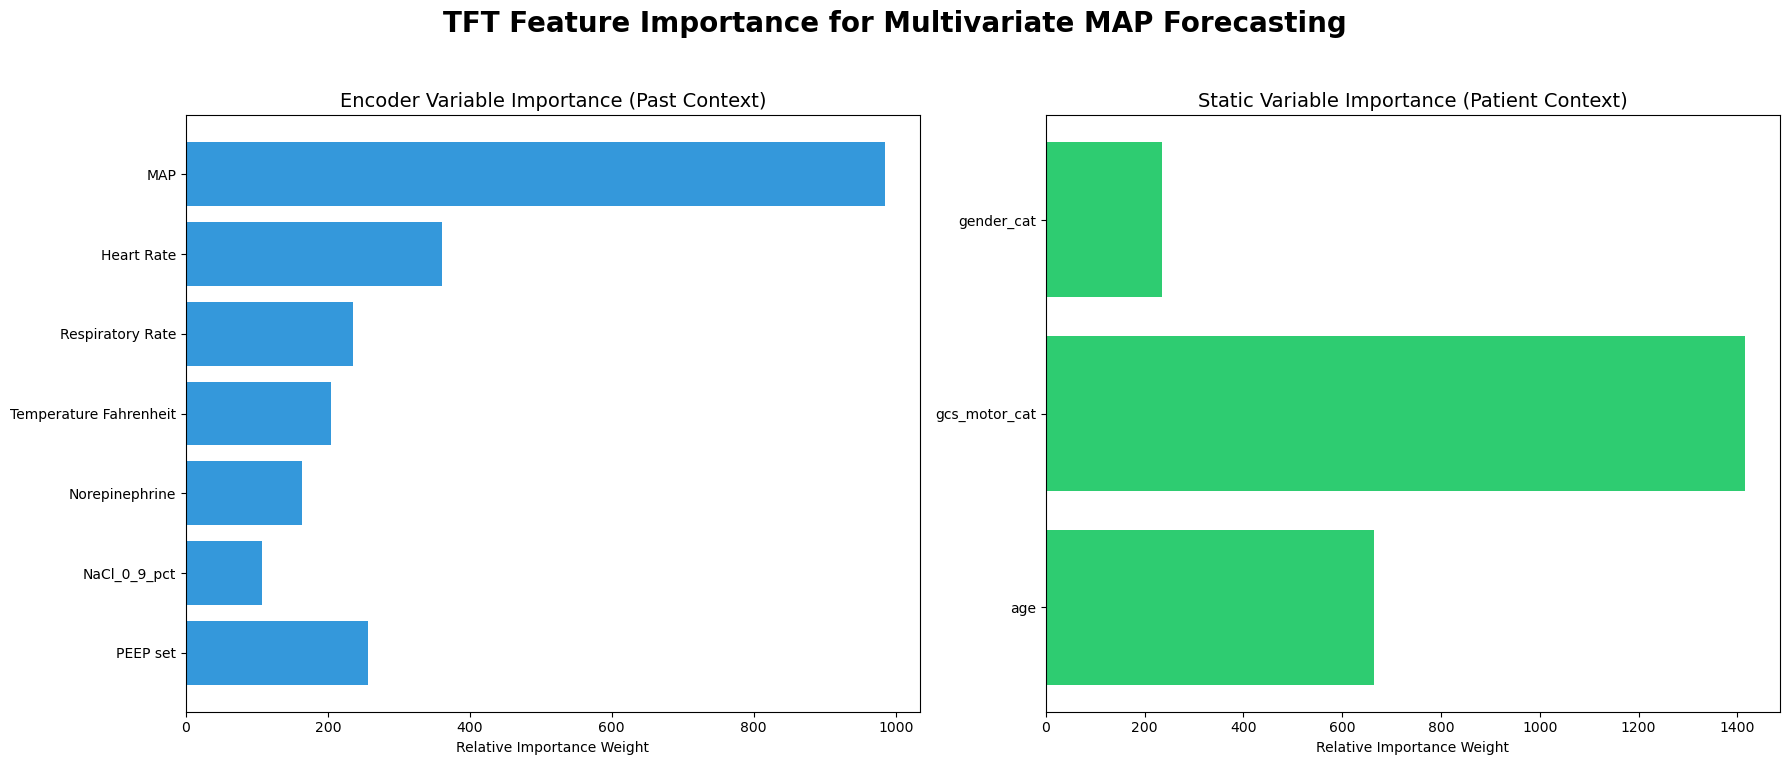

In [29]:
# 3. Plot Variable Importance
plot_tft_variable_importance(best_tft_multi, title_suffix="for Multivariate MAP Forecasting")

In [157]:
# 4. Evaluation and Visualisation
predictions_tft_multivariate, actuals_tft_multivariate, x_metadata_multivariate = evaluate_tft(
    model=best_tft_multi, 
    train_dataloader=train_loader_multi,
    test_dataloader=test_loader_multi, 
    scaler_std=scaler_std
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/homebrew/Caskroom/miniforge/base/envs/molecular-prediction/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `predict_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/lit


Horizon    | Train MAE  | Test MAE   | Gap       
---------------------------------------------
t+1 hour    | 6.65       | 7.84       | 1.19      
t+3 hour    | 6.99       | 8.63       | 1.64      
t+6 hour    | 7.22       | 9.08       | 1.86      
---------------------------------------------



### Visualisation for specific target_stay_ids

In [ ]:
def get_tft_predictions_for_plot(model, dataloader, scaler_std):
    """
    Extracts predictions and maps them to original Stay IDs.
    Returns a dictionary for easy lookup: {group_ids: pred_array}
    """
    # 1. Get raw point predictions
    # mode="prediction" returns the 0.5 quantile/point forecast automatically
    output = model.predict(dataloader, mode="prediction", return_x=True)
    preds_scaled = output.output.cpu().numpy()
    
    # 2. Extract Stay IDs directly from metadata
    # We convert to int to ensure matching with your target_stay_ids list
    stay_ids = output.x['groups'].cpu().numpy().flatten().astype(int)
    
    # 3. Inverse scale to mmHg
    map_std, map_mean = scaler_std.scale_[0], scaler_std.mean_[0]
    preds_mmhg = (preds_scaled * map_std) + map_mean
    
    # 4. Create lookup dictionary (always takes the latest window per patient)
    results_map = {}
    for sid, pred in zip(stay_ids, preds_mmhg):
        results_map[sid] = pred
        
    return results_map

# Execute once for both models
tft_uni_results = get_tft_predictions_for_plot(best_tft_uni, test_loader_uni, scaler_std)
tft_multi_results = get_tft_predictions_for_plot(best_tft_multi, test_loader_multi, scaler_std)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with th

In [138]:
target_stay_ids = [34617352, 38197705, 30585761, 32453351, 31316840, 32391858, 39804682, 37323533]

These steps are done because tft converted stay_id into its own categorical_id

In [139]:
stay_id_list = list(df_test['stay_id'].unique())

In [ ]:
target_stay_ids_to_cat = {}
# 85 came from the fact that the data loader converted test data starting with id 85 to 110
for i in range(26):
    target_stay_ids_to_cat[stay_id_list[i]] = i + 85
target_stay_ids_to_cat

{np.int64(34592300): 85,
 np.int64(31205490): 86,
 np.int64(32155744): 87,
 np.int64(31316840): 88,
 np.int64(34170353): 89,
 np.int64(34617352): 90,
 np.int64(31959184): 91,
 np.int64(31338022): 92,
 np.int64(37057036): 93,
 np.int64(35436337): 94,
 np.int64(35727289): 95,
 np.int64(32283063): 96,
 np.int64(30849778): 97,
 np.int64(35044342): 98,
 np.int64(38197705): 99,
 np.int64(30913302): 100,
 np.int64(30585761): 101,
 np.int64(35024147): 102,
 np.int64(36091287): 103,
 np.int64(32453351): 104,
 np.int64(32391858): 105,
 np.int64(35544374): 106,
 np.int64(34531557): 107,
 np.int64(39804682): 108,
 np.int64(37323533): 109,
 np.int64(36107367): 110}

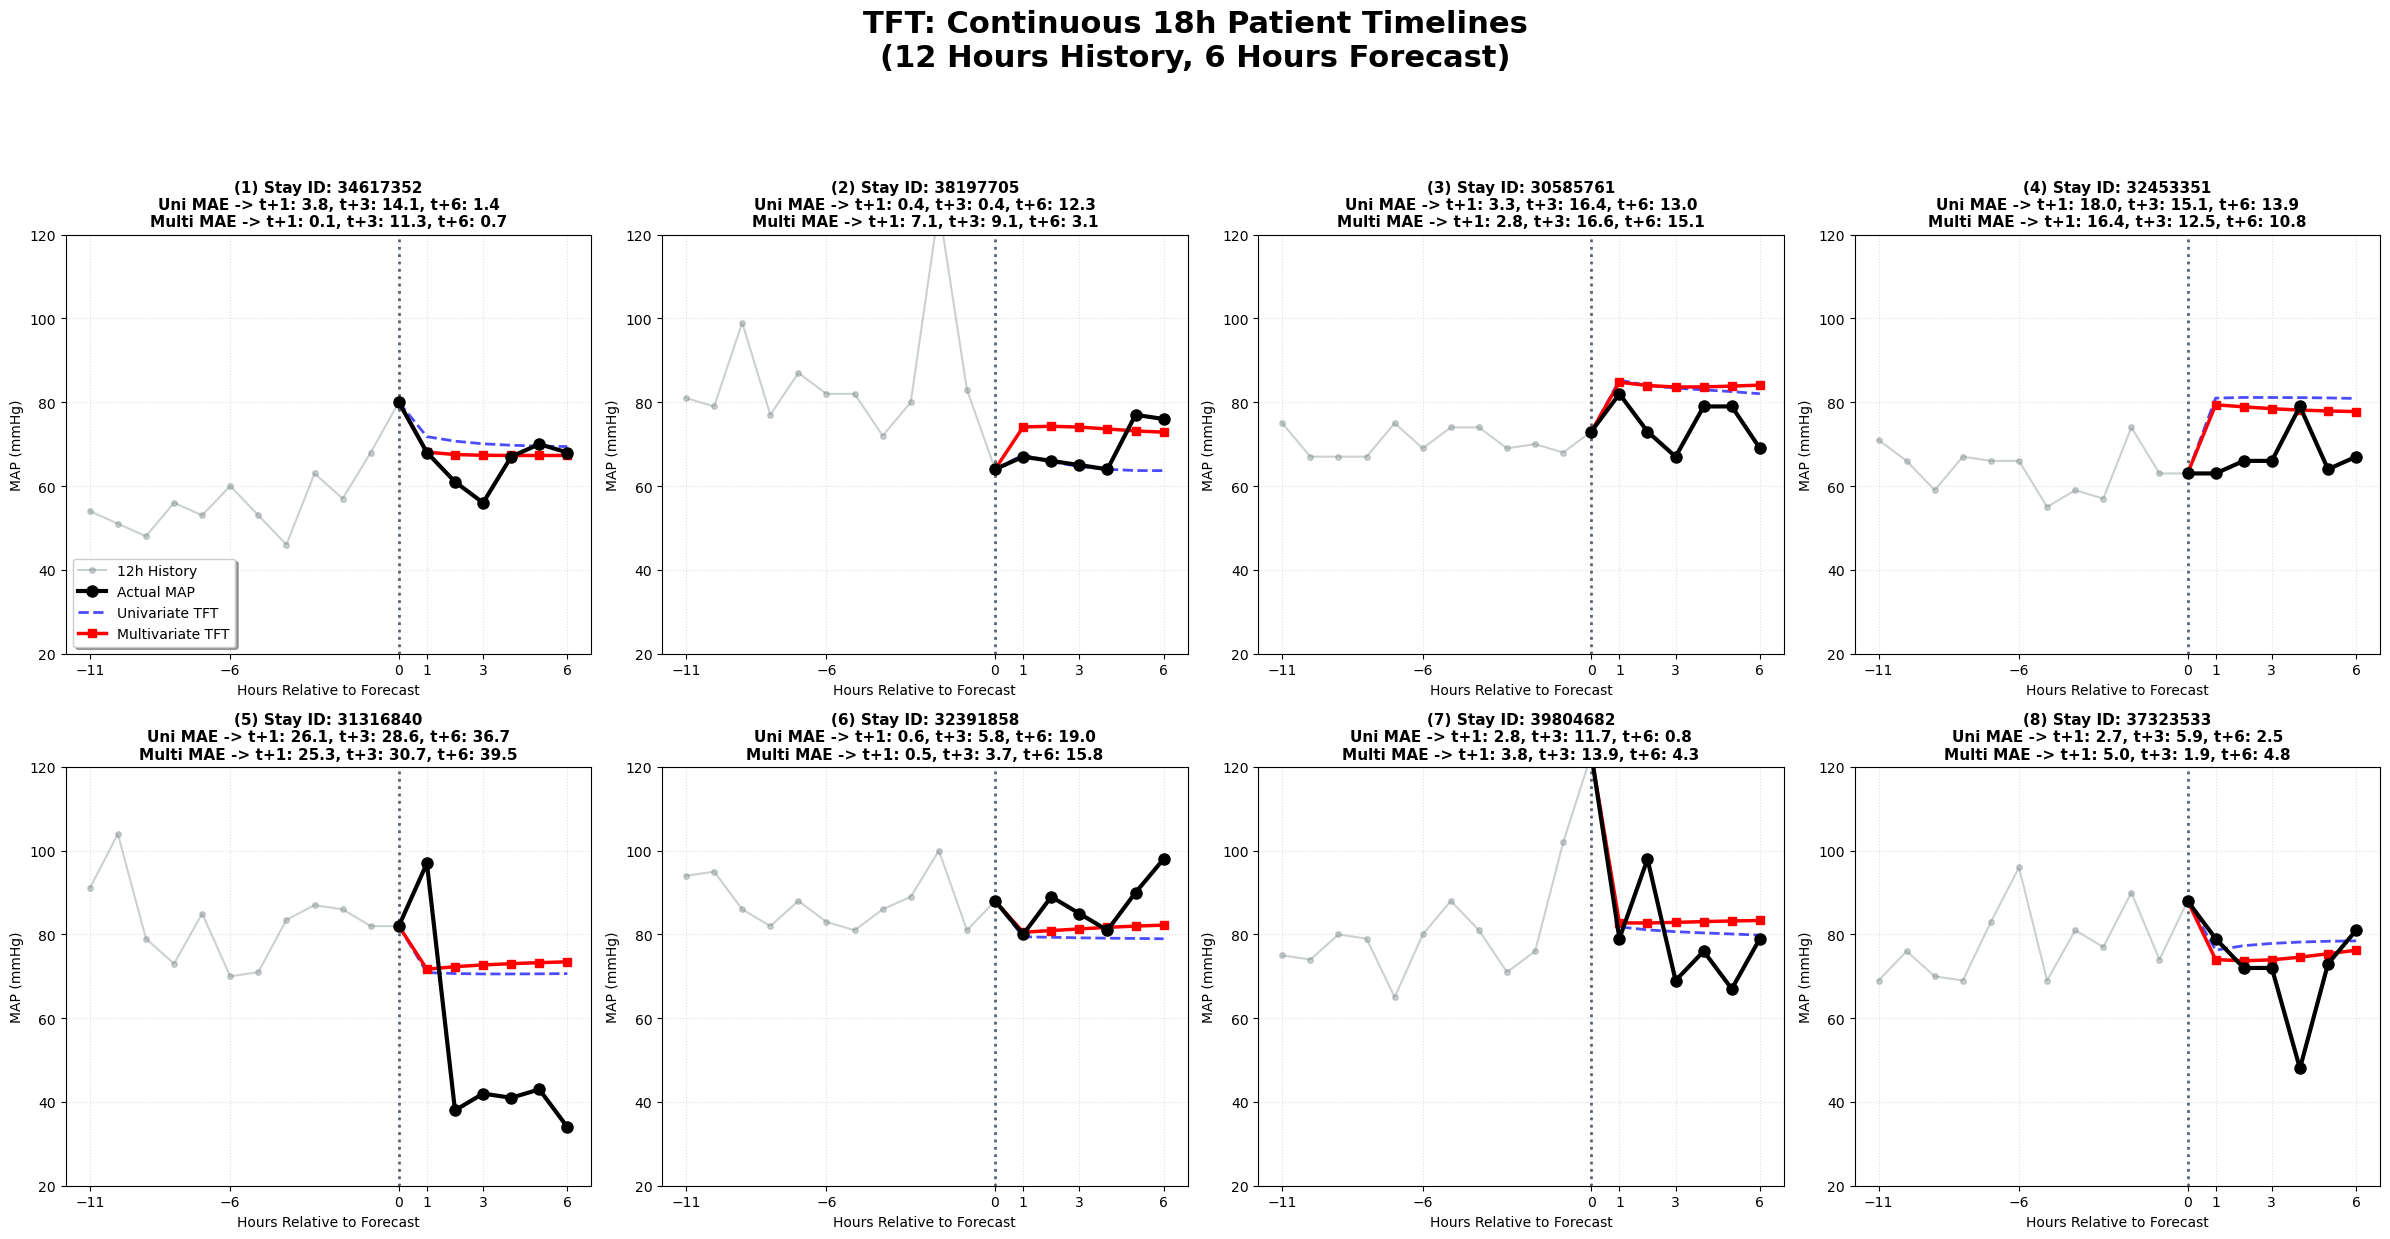

In [149]:
def plot_tft_clinical_comparison(target_ids, uni_results, multi_results, df_test, id_mapping):
    """
    Plots the final 18h window for 8 patients, comparing:
    TFT Univariate vs. TFT Multivariate.
    Numbered IDs (1-8) and Dual MAE metrics added for consistency.
    """
    fig, axes = plt.subplots(2, 4, figsize=(24, 13))
    fig.suptitle("TFT: Continuous 18h Patient Timelines\n(12 Hours History, 6 Hours Forecast)", 
                 fontsize=22, fontweight='bold', y=0.98)

    for i, sid in enumerate(target_ids):
        ax = axes[i // 4, i % 4]
        
        # --- 0. Translate Real ID to Categorical Index ---
        cat_id = id_mapping.get(sid)
        
        # 1. Fetch History and Actuals from Raw df_test
        patient_full_history = df_test[df_test['stay_id'] == int(sid)].sort_values('charttime')
        
        if len(patient_full_history) == 0:
            ax.set_title(f"({i+1}) Stay ID: {sid}\n[ID NOT FOUND]", color='red')
            continue
            
        history_vals = patient_full_history.iloc[-18:-6]['MAP'].values
        history_hours = np.arange(-11, 1) 
        
        if len(history_vals) == 0:
            ax.set_title(f"({i+1}) Stay ID: {sid}\n[INSUFFICIENT DATA]", color='orange')
            continue
            
        last_hist_val = history_vals[-1]
        actual_vals = patient_full_history.iloc[-6:]['MAP'].values
        full_forecast_hours = np.arange(0, 7) 

        # --- 2. EXTRACT PREDICTIONS ---
        p_uni_raw = uni_results.get(cat_id)
        p_multi_raw = multi_results.get(cat_id)

        # --- 3. PLOTTING ---
        # A. History (Gray)
        ax.plot(history_hours, history_vals, color='#7f8c8d', linestyle='-', marker='o', 
                markersize=4, alpha=0.4, label="12h History")
        
        # B. Actuals (Black)
        ax.plot(full_forecast_hours, np.insert(actual_vals, 0, last_hist_val), 
                'k-o', label="Actual MAP", linewidth=3, markersize=8, zorder=5)
        
        # C. Univariate TFT (Blue Dashed)
        u_mae_str = "N/A"
        if p_uni_raw is not None:
            p_uni = np.insert(p_uni_raw, 0, last_hist_val)
            ax.plot(full_forecast_hours, p_uni, 'b--', label="Univariate TFT", alpha=0.7, linewidth=2)
            u_mae1, u_mae3, u_mae6 = [np.abs(actual_vals[j] - p_uni_raw[j]) for j in [0, 2, 5]]
            u_mae_str = f"t+1: {u_mae1:.1f}, t+3: {u_mae3:.1f}, t+6: {u_mae6:.1f}"
            
        # D. Multivariate TFT (Red Solid)
        m_mae_str = "N/A"
        if p_multi_raw is not None:
            p_multi = np.insert(p_multi_raw, 0, last_hist_val)
            ax.plot(full_forecast_hours, p_multi, 'r-s', label="Multivariate TFT", linewidth=2.5)
            m_mae1, m_mae3, m_mae6 = [np.abs(actual_vals[j] - p_multi_raw[j]) for j in [0, 2, 5]]
            m_mae_str = f"t+1: {m_mae1:.1f}, t+3: {m_mae3:.1f}, t+6: {m_mae6:.1f}"

        # --- 4. FORMATTING & TITLE ---
        title_str = (f"({i+1}) Stay ID: {sid}\n"
                     f"Uni MAE -> {u_mae_str}\n"
                     f"Multi MAE -> {m_mae_str}")
        
        ax.set_title(title_str, fontsize=11, fontweight='semibold')
        ax.axvline(0, color='#2c3e50', linestyle=':', linewidth=2, alpha=0.8)
        ax.set_ylim(20, 120)
        ax.set_xticks([-11, -6, 0, 1, 3, 6])
        ax.set_xlabel("Hours Relative to Forecast", fontsize=10)
        ax.set_ylabel("MAP (mmHg)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.4)
        
        if i == 0:
            ax.legend(loc='lower left', fontsize=10, frameon=True, shadow=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    plt.show()

# --- RUN VISUALISATION ---
plot_tft_clinical_comparison(
    target_stay_ids, 
    tft_uni_results, 
    tft_multi_results, 
    df_test, 
    target_stay_ids_to_cat
)

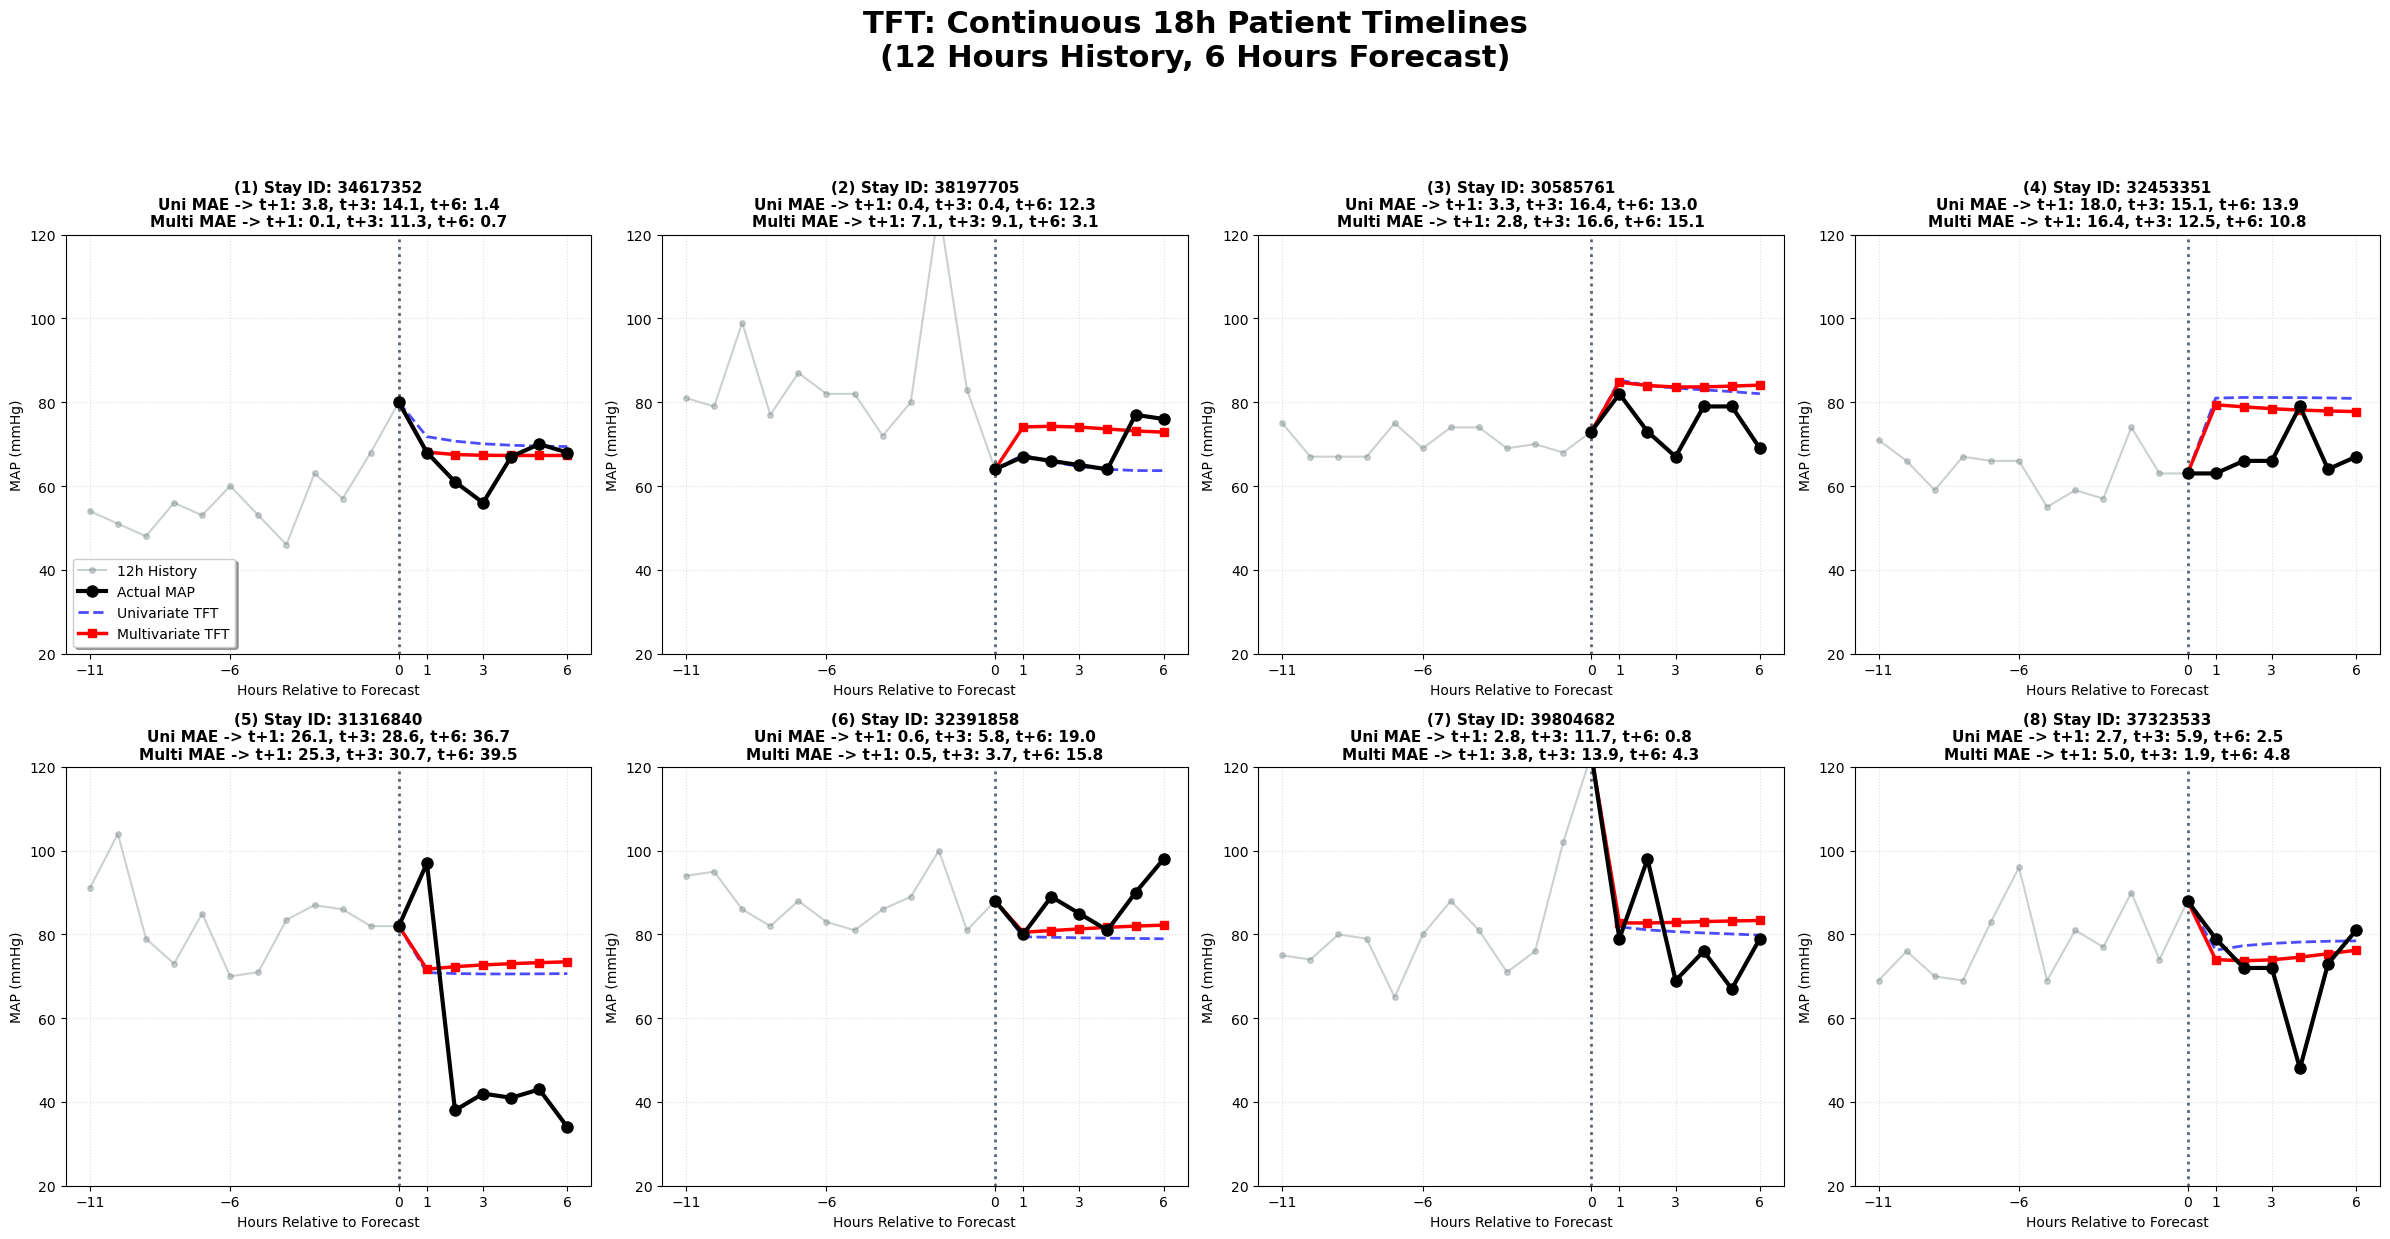

In [150]:
plot_tft_clinical_comparison(
    target_stay_ids, 
    tft_uni_results, 
    tft_multi_results, 
    df_test, 
    target_stay_ids_to_cat
)

In [146]:
tft_data = []
for sid in target_stay_ids:
    cat_id = target_stay_ids_to_cat.get(sid)
    if cat_id in tft_multi_results:
        tft_data.append({'stay_id': sid, 'preds': tft_multi_results[cat_id]})
tft_visual_df = pd.DataFrame(tft_data)
tft_visual_df

,stay_id,preds
0,34617352,"[68.07519254199411, 67.51768301399302, 67.3338..."
1,38197705,"[74.10501990301958, 74.25864972740177, 74.0753..."
2,30585761,"[84.79114123174811, 83.99597133629281, 83.6415..."
3,32453351,"[79.38747525103857, 78.90701715635075, 78.4597..."
4,31316840,"[71.69787957013253, 72.30883771780465, 72.7226..."
5,32391858,"[80.53351005790978, 80.9237889566866, 81.32233..."
6,39804682,"[82.7515704086419, 82.74268770159946, 82.88385..."
7,37323533,"[74.00521560832973, 73.70848994481655, 73.9365..."


In [151]:
tft_visual_df.to_csv('tft_visual.csv', index=False)